In [1]:
import pickle

import feyn

import numpy as np
import pandas as pd
import torch
from autora.theorist.bms import BMSRegressor
from gplearn.genetic import SymbolicRegressor
from kan import KAN, create_dataset
from kan.utils import ex_round
from matplotlib import font_manager
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

This version of Feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at https://abzu.ai/eula.

# KAN、遗传编程与贝叶斯方法的符号回归对比
本笔记本在同一任务下比较四种**符号回归**方法，对目标**单变量**函数进行建模：
$$
y = x^2 + x + 1
$$

1. **Kolmogorov-Arnold Networks (KAN)**：使用官方 **PyKAN** 进行训练。
2. **遗传编程（Genetic Programming）**：使用 **gplearn**，通过进化搜索符号表达式。
3. **贝叶斯符号回归（BSR）**：使用 [autora](https://pypi.org/project/autora/) 完成贝叶斯建模。
4. **QLattice**：QLattice 是 [SRBench Competition 2022](https://cavalab.org/srbench/competition-2022/) Synthetic Track 冠军方案。

## 数据集与可视化

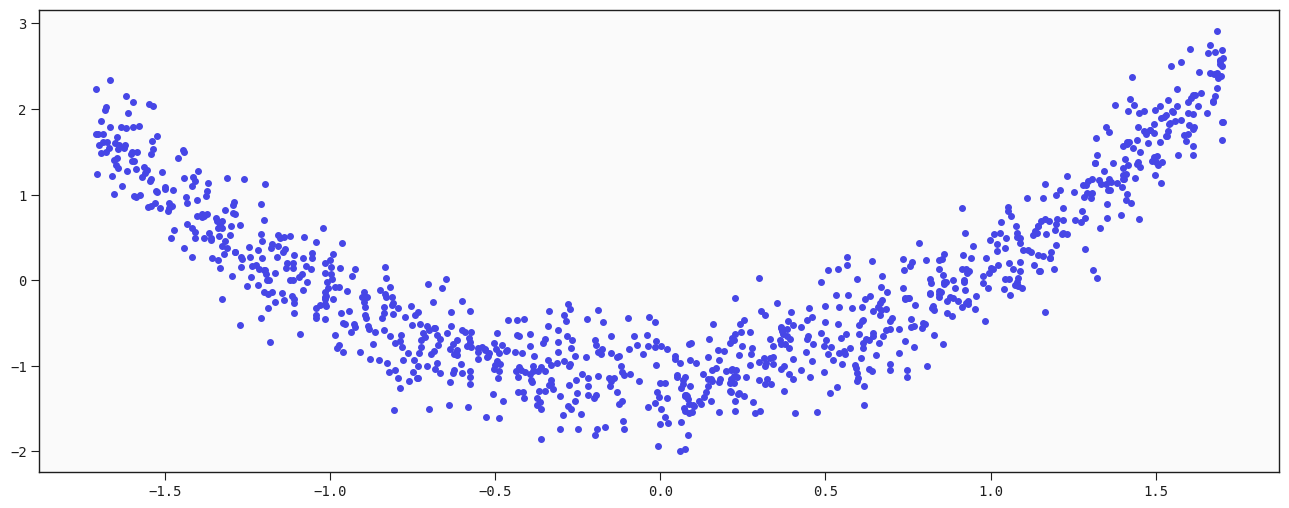

In [2]:
quadratic = lambda x: x ** 2 + x + 1
noise_std = .35
dataset = create_dataset(quadratic, n_var=1, ranges=[-10, 10], train_num=1000, test_num=500,
                         normalize_label=True, normalize_input=True)
dataset['train_label'] += np.random.normal(0, noise_std, (1000, 1))
Xs, Ys = dataset['train_input'], dataset['train_label']

fig, ax = plt.subplots()
ax.scatter(Xs, Ys)
fig.set_size_inches(16, 6)
plt.show()

## 1. KAN 方法

In [3]:
# kan_model = KAN.loadckpt('model/univariate_kan_model')
# kan_model.plot()

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.45e-01 | test_loss: 2.04e-02 | reg: 4.99e+00 | : 100%|█| 20/20 [00:01<00:00, 12.53it


saving model version 0.1


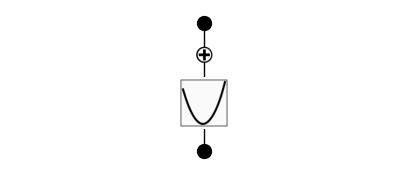

In [4]:
kan_model = KAN(width=[1, 1], grid=3, k=3)
kan_model.fit(dataset, opt='LBFGS', steps=20, lamb=0.001, lamb_entropy=4)
kan_model.plot()

In [5]:
kan_model.suggest_symbolic(0, 0, 0)
kan_model.auto_symbolic()
pass

   function  fitting r2    r2 loss  complexity  complexity loss  total loss
0       x^2    0.999938 -13.759480           2                2   -1.151896
1       sin    0.999752 -11.917594           2                2   -0.783519
2       cos    0.999747 -11.894493           2                2   -0.778899
3  gaussian    0.999896 -13.093281           3                3   -0.218656
4         0    0.000000   0.000014           0                0    0.000003
fixing (0,0,0) with x^2, r2=0.999937891960144, c=2
saving model version 0.2


In [6]:
kan_model.fit(dataset, opt='LBFGS', steps=20, lamb=0.001, lamb_entropy=4)
formula = kan_model.symbolic_formula()[0][0]
ex_round(formula, 3)

| train_loss: 3.45e-01 | test_loss: 1.81e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 44.53it


saving model version 0.3


1.108*(-x_1 - 0.084)**2 - 1.131

In [7]:
# kan_model.saveckpt('model/univariate_kan_model')

## 2. Gplearn 方法

In [8]:
# with open("univariate_gplearn_model.pkl", "rb") as f:
#     genetic_model: SymbolicRegressor = pickle.load(f)

In [9]:
# Configuration of the symbolic regressor
genetic_model = SymbolicRegressor(
    population_size=2000,
    generations=20,
    tournament_size=30,
    stopping_criteria=0.01,
    const_range=(-1.0, 1.0),
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.1,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    parsimony_coefficient=0.01,
    random_state=0
)

In [10]:
genetic_model.fit(Xs, Ys)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    46.41           7551.2        7         0.380742         0.334788     30.80s
   1     9.63          1.69581        5         0.336607         0.344353     15.48s
   2     7.95          5.71808       13         0.297181         0.292437     15.30s
   3     7.66          1.66844        9         0.289629         0.287356     14.99s
   4     5.65          1.13926        9         0.286949         0.311473     12.08s
   5     5.43          1.01164        9         0.285625         0.323397     10.81s
   6     6.41          1.22227        9         0.283614         0.341493     10.66s
   7     7.07          1.00453        9         0.285018         0.328853     10.22s
   8     7.21          2.03497        7         0.286108         0.364459  

SymbolicRegressor(max_samples=0.9, p_crossover=0.7, p_hoist_mutation=0.1,
                  p_point_mutation=0.1, p_subtree_mutation=0.1,
                  parsimony_coefficient=0.01, population_size=2000,
                  random_state=0, stopping_criteria=0.01, tournament_size=30,
                  verbose=1)

In [11]:
# with open("univariate_gplearn_model.pkl", "wb") as f:
#     pickle.dump(genetic_model, f)

## 3. BMS Regressor 方法

In [12]:
# with open("univariate_bms_model.pkl", "rb") as f:
#     bms_model: BMSRegressor = pickle.load(f)

In [13]:
bms_model = BMSRegressor(
    epochs=200,
    ts=[1.0] + [1.04 ** k for k in range(1, 20)],
)

In [14]:
bms_model.fit(Xs, Ys)

BMS fitting started

100%|██████████| 200/200 [00:59<00:00,  3.34it/s]


BMS fitting finished

(-1.01 + abs((X0 * X0)))

In [15]:
# with open("univariate_bms_model.pkl", "wb") as f:
#         pickle.dump(bms_model, f)

## 4. QLattice 方法

In [16]:
# with open("univariate_qlattice_model.pkl", "rb") as f:
#     qlattice_models: list[Model] = pickle.load(f)

In [17]:
ql = feyn.QLattice()
data = pd.DataFrame({
    'x': Xs.flatten(),
    'y': Ys.flatten()
})
qlattice_models = ql.auto_run(data, output_name='y', n_epochs=20)

In [18]:
qlattice_models[0].fit(data)
with open("univariate_qlattice_model.pkl", "wb") as f:
    pickle.dump(qlattice_models, f)

In [19]:
sympy_model = qlattice_models[0].sympify(signif=2)
sympy_model.as_expr()

1.1*(x + 0.085)**2 - 1.1

## 模型结果对比

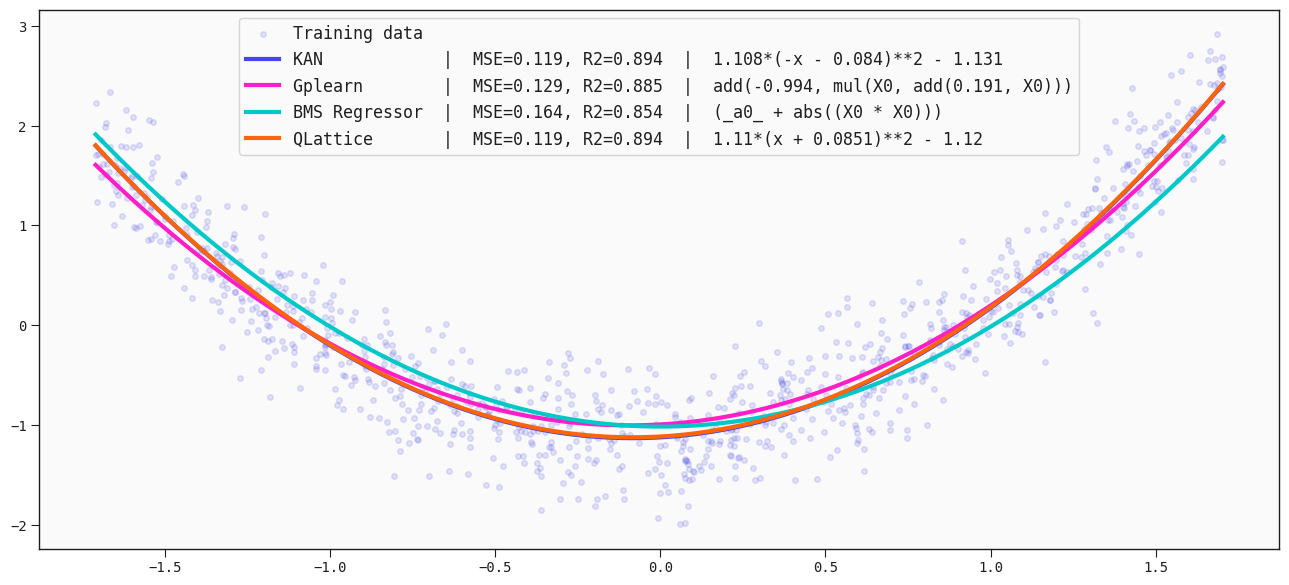

In [20]:
# Get the models predictions
with torch.no_grad():
    kan_pred = kan_model(Xs)
    genetic_pred = genetic_model.predict(Xs)
    bms_pred = bms_model.predict(Xs)
    qlattice_pred = qlattice_models[0].predict(pd.DataFrame({
        'x': Xs.flatten(),
    }))

models = [('KAN', kan_pred, ex_round(kan_model.symbolic_formula(var=['x'])[0][0], 3)),
          ('Gplearn', genetic_pred, genetic_model._program),
          ('BMS Regressor', bms_pred, bms_model.model_),
          ('QLattice', qlattice_pred, qlattice_models[0].sympify(signif=3))]
fig, ax = plt.subplots()
ax.scatter(Xs, Ys, label='Training data', alpha=0.15)
for pred in models:
    sorted_idx = np.argsort(Xs[:, 0])
    mse, r2 = mean_squared_error(Ys, pred[1]), r2_score(Ys, pred[1])
    ax.plot(Xs[sorted_idx], pred[1][sorted_idx],
            label=f'{pred[0]}{" " * (max(map(lambda x: len(x[0]), models)) - len(pred[0]))}  |  MSE={round(mse, 3)}, R2={round(r2, 3)}  |  {pred[2]}')

fig.set_size_inches(16, 7)
plt.legend(prop=font_manager.FontProperties(family='monospace', size=12))
plt.show()